In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
%matplotlib inline
uploaded = files.upload()
bank_knn_filename =next(iter(uploaded))
b_knn = pd.read_csv(io.StringIO(uploaded[bank_knn_filename].decode('utf-8')))
display(b_knn.head())

Saving bank_knn.csv to bank_knn.csv


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


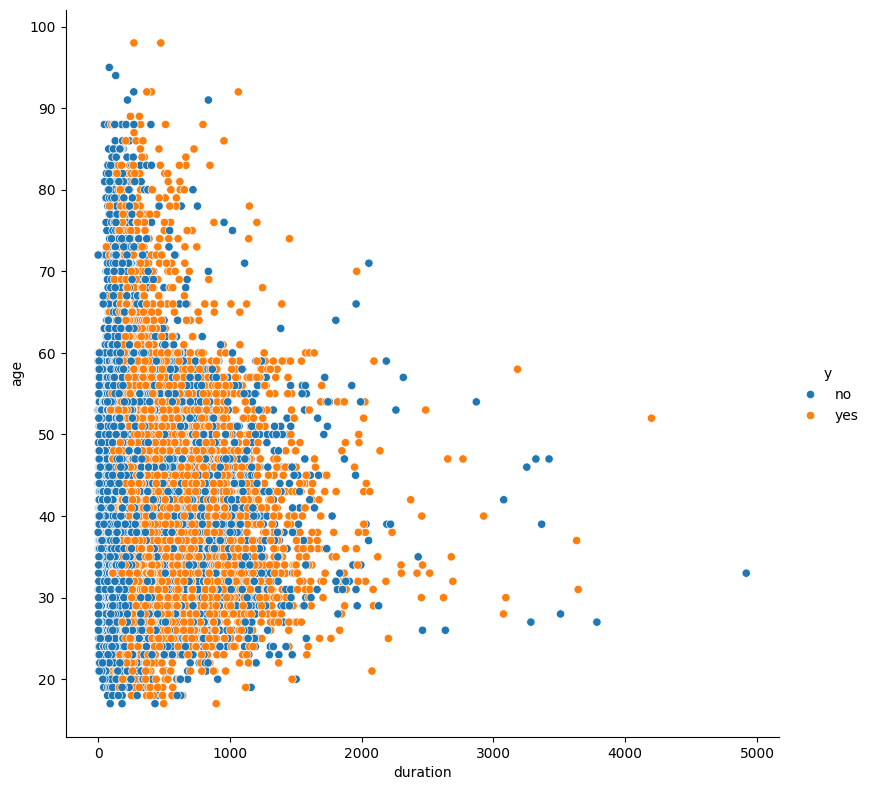

In [6]:
import seaborn as sns
sns.pairplot(b_knn,hue="y",
             x_vars="duration",y_vars="age",height=8)

In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_to_scale = ["duration","age"]
scaled_values = scaler.fit_transform(b_knn[features_to_scale])
b_knn["norm_duration"] = scaled_values[:,0]
b_knn["norm_age"] = scaled_values[:,1]
display(b_knn.head())


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,norm_duration,norm_age
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0.053070,0.481481
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0.030297,0.493827
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0.045954,0.246914
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0.030704,0.283951
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0.062424,0.481481


In [13]:
from sklearn.model_selection import train_test_split
X=b_knn[['norm_duration','norm_age']]
Y=b_knn['y']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.4,random_state=100)


In [14]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=200,metric="euclidean")
model.fit(X_train,Y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=200)

In [15]:
train_accuracy = model.score(X_train,Y_train)
test_accuracy = model.score(X_test,Y_test)
print("Train accuracy = ",train_accuracy)
print("Test accuracy = ",test_accuracy)

Train accuracy =  0.8943023632243444
Test accuracy =  0.8939062879339645


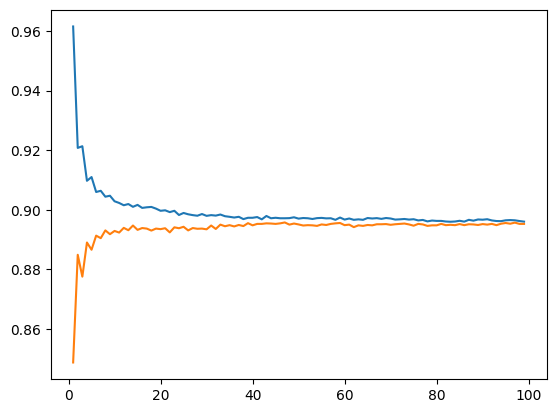

In [18]:
train_accuracies = []
test_accuracies = []
k_values = [i for i in range(1,100)]
features = ["norm_duration","norm_age"]
target = "y"
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k,metric='euclidean')
    model.fit(X_train,Y_train)
    train_accuracy = model.score(X_train,Y_train)
    test_accuracy = model.score(X_test,Y_test)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
plt.plot(k_values,train_accuracies,label="Train accuracy")
plt.plot(k_values,test_accuracies,label="Test accuracy")
